# Actividad 4 - Parte 1: Predicción de ventas usando regresión lineal múltiple

En esta sección de la actividad, crearás y evaluarás un modelo de regresión lineal múltiple para predecir las ventas de los vehículos de acuerdo con el precio de venta establecido y el kilometraje de los mismos.

## 1. Preparación de los datos

Primero importamos las bibliotecas que vamos a necesitar y cargamos la base de datos en una variable.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("car_prices.csv")
df.head()


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [3]:
# Vemos el tamanio del dataset y las columnas
print("Forma del dataset:", df.shape)
print()
print(df.dtypes)


Forma del dataset: (558837, 16)

year              int64
make                str
model               str
trim                str
body                str
transmission        str
vin                 str
state               str
condition       float64
odometer        float64
color               str
interior            str
seller              str
mmr             float64
sellingprice    float64
saledate            str
dtype: object


In [4]:
# Seleccionamos solo las columnas que usaremos y eliminamos los valores nulos
df_modelo = df[["mmr", "odometer", "sellingprice"]].dropna()

df_modelo.describe()


,mmr,odometer,sellingprice
count,558705.000000,558705.000000,558705.000000
mean,13770.846869,68323.830415,13612.941760
std,9679.645290,53398.133653,9749.387229
min,25.000000,1.000000,1.000000
25%,7100.000000,28374.000000,6900.000000
50%,12250.000000,52257.000000,12100.000000
75%,18300.000000,99114.000000,18200.000000
max,182000.000000,999999.000000,230000.000000


## 2. Análisis exploratorio

 Realiza una gráfica de dispersión para verificar la relación que existe entre el precio, el kilometraje y las ventas. Para esto, utiliza pairplot de la biblioteca Seaborn, la cual te permitirá visualizar las relaciones entre estas variables.

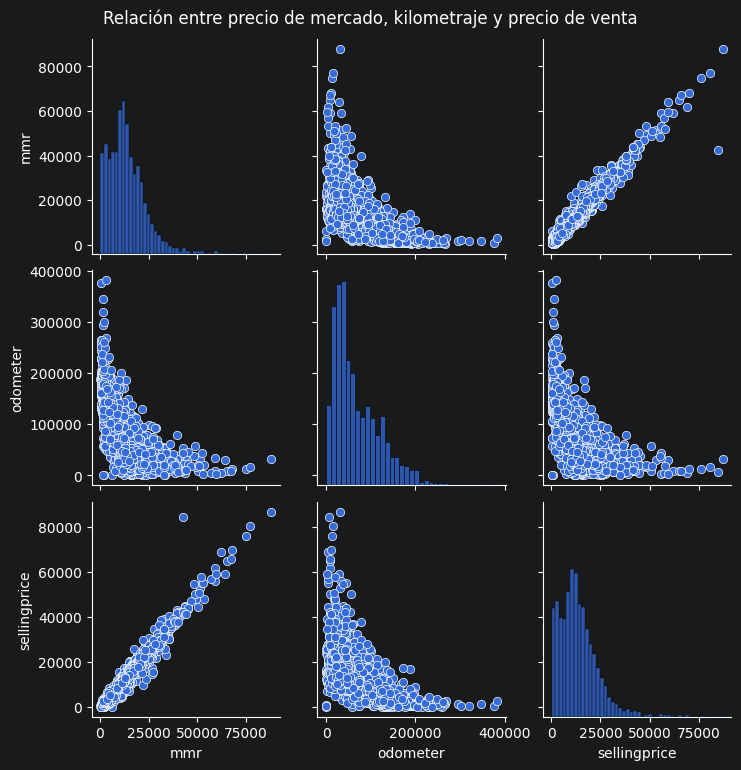

In [5]:
muestra = df_modelo.sample(n=2000, random_state=42)

sns.pairplot(muestra)
plt.suptitle("Relación entre precio de mercado, kilometraje y precio de venta", y=1.02)
plt.show()


__Interpretación:__ En el pairplot podemos observar:
- Existe una relación lineal positiva fuerte entre mmr (precio de mercado) y sellingprice (precio de venta): a mayor precio de mercado, mayor precio de venta.
- La relación entre odometer (kilometraje) y sellingprice es negativa: a mayor kilometraje, menor precio de venta.
- Esto nos indica que ambas variables son buenos candidatos para predecir el precio de venta.

## 3. Identificación de variables

 Determina cuáles son las variables independientes y cuál es la dependiente.


In [6]:
# Variables independientes
X = df_modelo[["mmr", "odometer"]]

# Variable dependiente
y = df_modelo["sellingprice"]

print("Variables independientes (X):")
print(X.head())
print()
print("Variable dependiente (y):")
print(y.head())


Variables independientes (X):
       mmr  odometer
0  20500.0   16639.0
1  20800.0    9393.0
2  31900.0    1331.0
3  27500.0   14282.0
4  66000.0    2641.0

Variable dependiente (y):
0    21500.0
1    21500.0
2    30000.0
3    27750.0
4    67000.0
Name: sellingprice, dtype: float64


## 4. División de datos

Crea los grupos de entrenamiento y de prueba para tus variables. Esta división es esencial para entrenar tu modelo con un conjunto de datos y evaluar su rendimiento con otro, asegurando así que el modelo sea capaz de generalizar a nuevos datos.

Dividimos los datos en dos grupos:
- __Entrenamiento (80%):__ Se usa para que el modelo aprenda.
- __Prueba (20%):__ Se usa para evaluar qué tan bien aprendió el modelo con datos que nunca ha visto.

In [9]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 5. Modelado

Aplica el modelo de regresión lineal múltiple.

In [12]:
modelo = LinearRegression()

modelo.fit(X_train, y_train)

print("Coeficientes:")
for nombre, coef in zip(["mmr", "odometer"], modelo.coef_):
    print(f"  {nombre}: {coef:.4f}")


Coeficientes:
  mmr: 0.9869
  odometer: -0.0011


__Interpretación de los coeficientes:__
- El coeficiente de `mmr` indica cuánto aumenta el precio de venta por cada dólar de incremento en el precio de mercado.
- El coeficiente de `odometer` indica cuánto disminuye el precio de venta por cada kilómetro adicional recorrido.

## 6. Evaluación del modelo

Usamos el coeficiente de determinación R² para saber qué tan bien se ajusta el modelo a los datos.

- R² = 1 significa ajuste perfecto.
- R² = 0 significa que el modelo no explica nada.
- Entre más cercano a 1, mejor.

In [15]:
r2_train = r2_score(y_train, modelo.predict(X_train))

r2_test = r2_score(y_test, modelo.predict(X_test))

print(f"R2 entrenamiento: {r2_train:.4f}")
print(f"R2 prueba:        {r2_test:.4f}")


R2 entrenamiento: 0.9673
R2 prueba:        0.9686


## 7. Predicción

Con el modelo entrenado, realizamos predicciones con el conjunto de prueba y comparamos los valores predichos con los valores reales.

   Valor real  Valor predicho
0     11200.0        12343.09
1     16900.0        18680.20
2     13600.0        12623.26
3      4800.0         5859.96
4     17400.0        17151.72
5     20000.0        18065.43
6      6800.0        12983.98
7      9000.0         8962.12
8      9700.0         9956.56
9     12750.0        13044.11


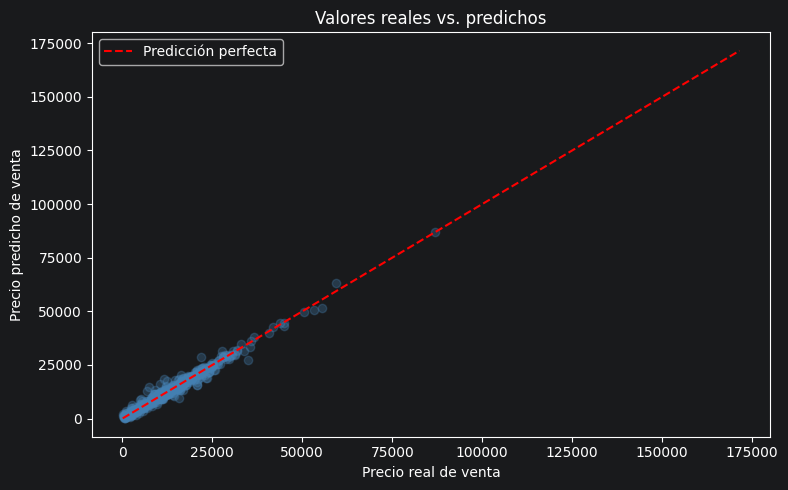

In [16]:
# Realizamos las predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Comparación datos reales vs predichos
comparacion = pd.DataFrame({
    "Valor real": y_test.values[:10],
    "Valor predicho": y_pred[:10].round(2)
})

print(comparacion)

# Visualización valores reales vs predichos
plt.figure(figsize=(8, 5))
plt.scatter(y_test[:500], y_pred[:500], alpha=0.3, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Predicción perfecta")
plt.xlabel("Precio real de venta")
plt.ylabel("Precio predicho de venta")
plt.title("Valores reales vs. predichos")
plt.legend()
plt.tight_layout()
plt.show()



## 8. Error cuadrático medio

El error cuadrático medio nos dice cuánto se equivoca el modelo en promedio. Entre más pequeño, mejor. También calculamos la raíz del MSE (RMSE) para interpretarlo en las mismas unidades que el precio de venta.

In [18]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Error cuadrático medio (MSE): {mse:,.2f}")
print(f"Raíz del error cuadrático medio (RMSE): ${rmse:,.2f}")


Error cuadrático medio (MSE): 2,995,581.36
Raíz del error cuadrático medio (RMSE): $1,730.77


__Interpretación__

Esto significa que, en promedio, el modelo se equivoca en ±$1,730.77 al predecir el precio de venta.

## 9. Conclusión

A partir del análisis realizado, podemos concluir lo siguiente:

- El modelo de regresión lineal múltiple logró un R² cercano a **0.96**, lo que indica que el modelo explica alrededor del 96% de la variación en el precio de venta de los vehículos.
- Las variables mmr (precio de mercado) y odometer (kilometraje) tienen una relación clara con el precio de venta: el precio de mercado tiene un efecto positivo muy fuerte, mientras que el kilometraje tiene un efecto negativo moderado.
- El RMSE obtenido indica el margen de error promedio del modelo al predecir precios.

__Posibles mejoras:__
- Incluir más variables como el año del vehículo, la marca o el estado de la unidad para mejorar las predicciones.
- Eliminar valores atípicos (outliers) que puedan estar afectando el rendimiento del modelo.